# UPI Guardian - M1 behaviour model (Kaggle-ready)
Runs as-is on Kaggle (**Add data** -> *Digital Payment Fraud Detection Benchmark* by rohit8527kmr7518) or locally from this repository.
It reproduces `ml/train_behaviour.py`: strict time split, XGBoost with early stopping on PR-AUC, SHAP.
Download `behaviour_model.joblib` from the notebook output and place it in `models/` to use it in the app.

In [1]:
import os, math, json
from pathlib import Path
import numpy as np, pandas as pd, xgboost as xgb, joblib
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
KAGGLE_DIR = Path("/kaggle/input/digital-payment-fraud-detection-benchmark")
LOCAL_DIR = (Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()) / "data/raw/payment_fraud_benchmark"
DATA = KAGGLE_DIR if KAGGLE_DIR.exists() else LOCAL_DIR
OUT = Path("/kaggle/working") if KAGGLE_DIR.exists() else Path.cwd()
print("reading from", DATA)

reading from D:\abstracts\Madhav\CSDS\B\CSDS-B-B4\8.ProjectCode\data\raw\payment_fraud_benchmark


In [2]:
FEATURES = ["log_amount","amount_deviation_from_user_mean","avg_monthly_spend","account_age_days","txn_count_1h","txn_count_24h",
            "failed_txn_count_24h","geo_distance_from_last_txn","merchant_risk_score","is_international","hour_sin","hour_cos",
            "device_mobile","device_desktop","device_tablet"]
def frame(df):
    h = df.transaction_time.dt.hour + df.transaction_time.dt.minute / 60
    return pd.DataFrame({
        "log_amount": np.log1p(df.transaction_amount.clip(lower=0)),
        "amount_deviation_from_user_mean": df.amount_deviation_from_user_mean,
        "avg_monthly_spend": df.avg_monthly_spend,
        "account_age_days": df.account_age_days.clip(30, 2000).astype(float),
        "txn_count_1h": df.txn_count_1h.astype(float), "txn_count_24h": df.txn_count_24h.astype(float),
        "failed_txn_count_24h": df.failed_txn_count_24h.astype(float),
        "geo_distance_from_last_txn": df.geo_distance_from_last_txn.astype(float),
        "merchant_risk_score": df.merchant_risk_score, "is_international": df.is_international.astype(float),
        "hour_sin": np.sin(2*np.pi*h/24), "hour_cos": np.cos(2*np.pi*h/24),
        "device_mobile": (df.device_type=="mobile").astype(float), "device_desktop": (df.device_type=="desktop").astype(float),
        "device_tablet": (df.device_type=="tablet").astype(float)})[FEATURES]
train = pd.read_csv(DATA/"transactions_train.csv", parse_dates=["transaction_time"]).sort_values("transaction_time")
test = pd.read_csv(DATA/"transactions_test.csv", parse_dates=["transaction_time"]).sort_values("transaction_time")
fit, val = train[train.transaction_time < "2023-09-01"], train[train.transaction_time >= "2023-09-01"]
rng = np.random.default_rng(42)
x_fit = frame(fit); x_fit.loc[rng.random(len(x_fit)) < 0.5, "geo_distance_from_last_txn"] = np.nan
print(len(fit), len(val), len(test))

267224 32889 99887


In [3]:
model = xgb.XGBClassifier(n_estimators=1500, learning_rate=0.03, max_depth=4, min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
                          reg_lambda=2.0, tree_method="hist", eval_metric="aucpr", early_stopping_rounds=100, random_state=42, n_jobs=-1)
model.fit(x_fit, fit.is_fraud, eval_set=[(frame(val), val.is_fraud)], verbose=False)
s = model.predict_proba(frame(test))[:, 1]
print("best iteration", model.best_iteration, "| test PR-AUC", round(average_precision_score(test.is_fraud, s), 4), "| ROC-AUC", round(roc_auc_score(test.is_fraud, s), 4))

best iteration 272 | test PR-AUC 0.3504 | ROC-AUC 0.8439


D:\abstracts\Madhav\CSDS\B\CSDS-B-B4\8.ProjectCode\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


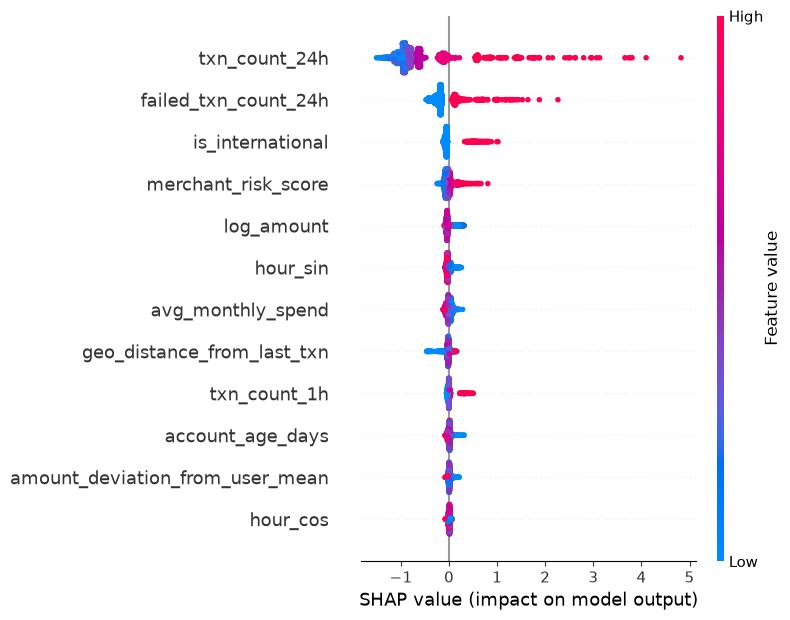

In [4]:
import shap
sample = frame(test).sample(2000, random_state=42)
sv = shap.TreeExplainer(model).shap_values(sample)
shap.summary_plot(sv, sample, show=True, max_display=12)

In [5]:
joblib.dump({"version": "m1-xgb-kaggle", "model": model, "features": FEATURES}, OUT / "behaviour_model_kaggle.joblib", compress=3)
print("saved", OUT / "behaviour_model_kaggle.joblib")

saved D:\abstracts\Madhav\CSDS\B\CSDS-B-B4\8.ProjectCode\notebooks\behaviour_model_kaggle.joblib
